<a href="https://colab.research.google.com/github/arsuscode/EDA-with-Kaggle-Dataset/blob/main/EDA_with_KaggleDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install library kaggle (biasanya sudah ada di Colab, tapi untuk memastikan)
!pip install -q kaggle

In [ ]:
# 2. Mengatur Environment Variable untuk API Token
import os
import getpass

print("Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:")
# getpass digunakan agar token yang Anda ketik tidak terlihat di layar
kaggle_token = getpass.getpass('KAGGLE_API_TOKEN: ')

# Menyetel environment variable agar library kaggle bisa membacanya
os.environ['KAGGLE_API_TOKEN'] = kaggle_token

print("\nOtentikasi API Kaggle Selesai!")

Silakan tempel (paste) API Token Kaggle Anda (dimulai dengan KGAT_...) dan tekan Enter:
KAGGLE_API_TOKEN: ··········

Otentikasi API Kaggle Selesai!


In [ ]:
# ---------------------------------------------------------
# 3. MENGUNDUH DATASET CONTOH
# Perintah: kaggle datasets download -d [nama-pemilik/nama-dataset]
# ---------------------------------------------------------
print("Mengunduh dataset Students Performance...")
!kaggle datasets download -d spscientist/students-performance-in-exams

Mengunduh dataset Students Performance...
Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
100% 8.70k/8.70k [00:00<00:00, 16.6MB/s]



In [ ]:
# 4. Mengekstrak file ZIP hasil unduhan
# -q artinya 'quiet' (tanpa log ekstraksi yang panjang)
!unzip -q students-performance-in-exams.zip -d dataset_siswa/

print("Unduhan dan Ekstraksi Selesai!")

Unduhan dan Ekstraksi Selesai!


In [ ]:
# ---------------------------------------------------------
# 5. MEMUAT DATA KE PANDAS (Langkah Awal EDA)
# ---------------------------------------------------------
import pandas as pd

# Membaca file CSV yang sudah diekstrak
# Sesuaikan nama file CSV dengan isi dari ZIP tersebut
df = pd.read_csv('dataset_siswa/StudentsPerformance.csv')

In [ ]:
# Menampilkan 5 baris pertama untuk memastikan koneksi dan load data berhasil
print("\n--- 5 Baris Pertama Dataset Students Performance ---")
display(df.head())


--- 5 Baris Pertama Dataset Students Performance ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## **Inspeksi Awal Data (Initial Data Inspection)**

 Tujuan Skrip

Skrip ini bertujuan untuk melakukan langkah-langkah awal dalam analisis data pada dataset 'Students Performance in Exams'. Secara spesifik, skrip ini meliputi:

1.  **Pengaturan Lingkungan**: Memastikan *library* Kaggle terinstal dan mengkonfigurasi token API Kaggle untuk akses dataset.
2.  **Pengunduhan dan Ekstraksi Data**: Mengunduh dataset 'Students Performance in Exams' dari Kaggle dan mengekstraknya ke dalam direktori lokal.
3.  **Pemuatan Data**: Memuat data dari file CSV yang sudah diekstrak ke dalam Pandas DataFrame untuk memudahkan manipulasi dan analisis.
4.  **Inspeksi Awal Data (Initial Data Inspection)**: Melakukan pemeriksaan awal terhadap struktur data, meliputi melihat beberapa baris pertama dan terakhir, mengetahui dimensi dataset (jumlah baris dan kolom), memeriksa tipe data setiap kolom, dan mendapatkan daftar nama kolom. Langkah ini penting untuk memahami karakteristik dasar data sebelum melakukan analisis lebih lanjut.

In [ ]:
# Tampilkan 5 baris pertama data
print("--- 5 Baris Pertama Data ---")
display(df.head())

# Tampilkan 5 baris terakhir data (opsional, untuk memastikan data dimuat utuh)
print("\n--- 5 Baris Terakhir Data ---")
display(df.tail())

# Cek dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

# Cek tipe data setiap kolom dan informasi penggunaan memori
print("\n--- Informasi Dataset (Tipe Data & Non-Null) ---")
df.info()

# Dapatkan nama-nama kolom
print("\n--- Daftar Nama Kolom ---")
print(df.columns.tolist())

--- 5 Baris Pertama Data ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75



--- 5 Baris Terakhir Data ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86



Dimensi dataset: 1000 baris, 8 kolom

--- Informasi Dataset (Tipe Data & Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

--- Daftar Nama Kolom ---
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


## Penjelasan Bagian-bagian Penting Skrip

Skrip ini terbagi menjadi beberapa bagian penting yang bekerja secara berurutan untuk mencapai tujuannya:

1.  **Instalasi dan Konfigurasi Kaggle API**: Ini adalah langkah persiapan awal yang memastikan lingkungan siap untuk berinteraksi dengan Kaggle. `!pip install -q kaggle` menginstal *library*, dan blok kode berikutnya (`import os`, `import getpass`, `os.environ[...]`) berfungsi untuk mengamankan dan mengesahkan akses ke akun Kaggle Anda menggunakan token API.

2.  **Pengunduhan dan Ekstraksi Dataset**: Setelah Kaggle API siap, skrip menggunakan perintah `!kaggle datasets download -d spscientist/students-performance-in-exams` untuk mengunduh dataset yang diinginkan. Kemudian, `!unzip -q ...` bertanggung jawab untuk mengekstrak file ZIP yang terunduh, membuatnya tersedia dalam format yang dapat dibaca.

3.  **Pemuatan Data ke Pandas DataFrame**: Bagian ini adalah inti dari manipulasi data. `import pandas as pd` mengimpor *library* Pandas, dan `df = pd.read_csv('dataset_siswa/StudentsPerformance.csv')` memuat data dari file CSV yang telah diekstrak ke dalam sebuah objek DataFrame (`df`). DataFrame adalah struktur data tabular yang sangat powerful di Pandas untuk analisis data.

4.  **Inspeksi Awal Data**: Setelah data dimuat, serangkaian perintah seperti `display(df.head())`, `display(df.tail())`, `df.shape`, `df.info()`, dan `df.columns.tolist()` digunakan untuk mendapatkan gambaran cepat tentang isi, ukuran, tipe data, dan kolom-kolom yang ada dalam dataset. Ini adalah langkah krusial dalam *Exploratory Data Analysis* (EDA) untuk mengidentifikasi potensi masalah atau memahami karakteristik data.

## **Pengecekan Kualitas Data Dasar** (Basic Data Quality Checks)

--- Pengecekan Missing Values ---


,Jumlah Missing,Persentase (%)


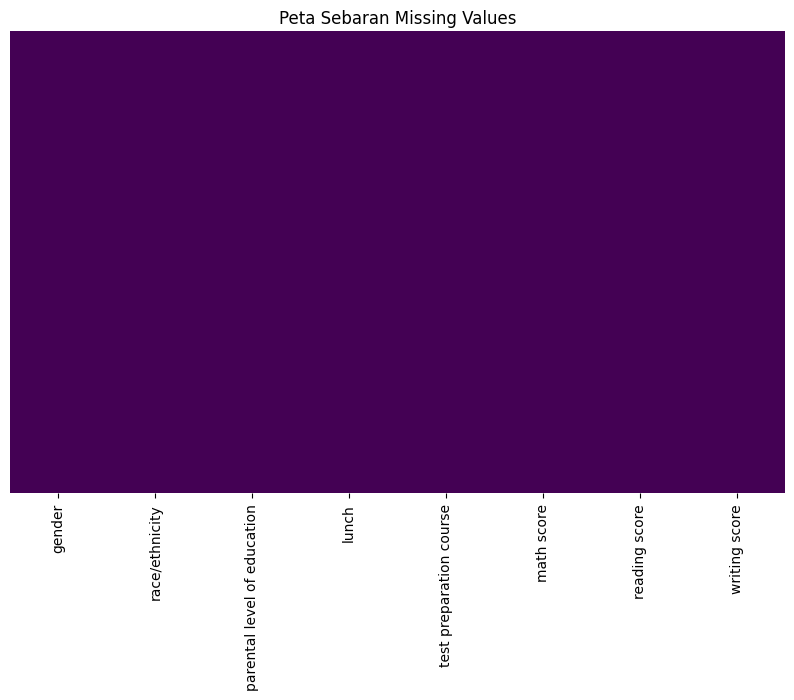


--- Pengecekan Data Duplikat ---
Jumlah baris duplikat identik: 0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Pengecekan Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.concat([missing_data, missing_percent], axis=1, keys=['Jumlah Missing', 'Persentase (%)'])
# Tampilkan hanya kolom yang memiliki missing value
display(missing_table[missing_table['Jumlah Missing'] > 0])

# Visualisasi Missing Values (Menggunakan Heatmap seaborn)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Sebaran Missing Values')
plt.show()

print("\n--- Pengecekan Data Duplikat ---")
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat identik: {jumlah_duplikat}")
# Jika ada, Anda bisa menampilkan contoh duplikatnya dengan mengaktifkan baris di bawah:
# if jumlah_duplikat > 0:
#     display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

### Ringkasan Pengecekan Kualitas Data

Berdasarkan pemeriksaan yang telah dilakukan:

*   **Tidak ada Missing Values**: Dataset ini tidak mengandung nilai yang hilang di kolom mana pun, menunjukkan kelengkapan data yang baik.
*   **Tidak ada Data Duplikat**: Tidak ditemukan baris yang terduplikat secara identik, menandakan setiap entri dalam dataset adalah unik.

Dengan hasil ini, kita dapat melanjutkan ke tahap analisis data selanjutnya dengan keyakinan bahwa data yang digunakan sudah bersih dan tidak memerlukan penanganan khusus untuk *missing values* atau duplikasi.

## **Statistik Deskriptif (Descriptive Statistics)**

In [ ]:
print("--- Statistik Deskriptif untuk Kolom Numerik ---")
display(df.describe())

print("\n--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---")
display(df.describe(include='object'))

--- Statistik Deskriptif untuk Kolom Numerik ---


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000



--- Statistik Deskriptif untuk Kolom Kategori (Objek) ---


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### Ringkasan Statistik Deskriptif

Setelah menganalisis statistik deskriptif untuk dataset "Students Performance in Exams", berikut adalah poin-poin utamanya:

**Untuk Kolom Numerik (`math score`, `reading score`, `writing score`):**
*   **Count**: Menunjukkan ada 1000 entri yang tidak kosong untuk setiap kolom nilai, artinya semua data lengkap.
*   **Mean (Rata-rata)**: Rata-rata nilai matematika adalah sekitar 66.09, membaca 69.17, dan menulis 68.05. Ini memberikan gambaran umum kinerja siswa. Terlihat bahwa nilai membaca sedikit lebih tinggi dibandingkan matematika dan menulis.
*   **Std (Standar Deviasi)**: Nilai standar deviasi (sekitar 14-15) menunjukkan sebaran nilai yang cukup besar di setiap mata pelajaran. Ini menandakan adanya variasi yang signifikan antara nilai siswa, dari yang sangat rendah hingga sangat tinggi.
*   **Min (Minimum)**: Ada siswa yang mendapatkan nilai 0 untuk matematika dan 10 untuk menulis, serta 17 untuk membaca. Ini menunjukkan keberadaan beberapa siswa dengan kinerja yang sangat rendah.
*   **25%, 50% (Median), 75%**: Ini adalah kuartil yang menunjukkan distribusi data. Misalnya, 50% siswa mendapatkan nilai matematika 66 atau kurang/lebih. Median yang dekat dengan *mean* menunjukkan distribusi yang relatif simetris, namun ada sedikit kemiringan (skewness) yang mungkin perlu diinvestigasi lebih lanjut (misalnya, nilai minimum 0 bisa mempengaruhi ini).
*   **Max (Maksimum)**: Nilai tertinggi di semua mata pelajaran adalah 100, menunjukkan ada siswa yang mencapai nilai sempurna.

**Untuk Kolom Kategori (`gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`):**
*   **Count**: Semua kolom memiliki 1000 entri, menegaskan tidak ada nilai yang hilang.
*   **Unique**: Menunjukkan jumlah kategori unik dalam setiap kolom (misalnya, 2 jenis *gender*, 5 kelompok *race/ethnicity*).
*   **Top**: Kategori yang paling sering muncul dalam setiap kolom. Contoh:
    *   `gender`: 'female' adalah gender yang paling banyak dengan 518 entri.
    *   `race/ethnicity`: 'group C' adalah kelompok ras/etnis terbesar dengan 319 entri.
    *   `parental level of education`: 'some college' adalah tingkat pendidikan orang tua yang paling umum dengan 226 entri.
    *   `lunch`: 'standard' adalah jenis makan siang yang paling banyak diambil (645 entri).
    *   `test preparation course`: 'none' (tidak mengambil kursus persiapan ujian) adalah yang paling sering (642 entri).
*   **Freq**: Frekuensi (jumlah kemunculan) dari kategori 'top' tersebut.

Statistik deskriptif ini memberikan pemahaman awal yang baik tentang karakteristik pusat, sebaran, dan distribusi data numerik, serta komposisi kategori dalam dataset. Informasi ini krusial untuk langkah-langkah *Exploratory Data Analysis* (EDA) selanjutnya.

## **Analisis Univariat (Univariate Analysis)**

### Analisis Univariat untuk Kolom Numerik ###


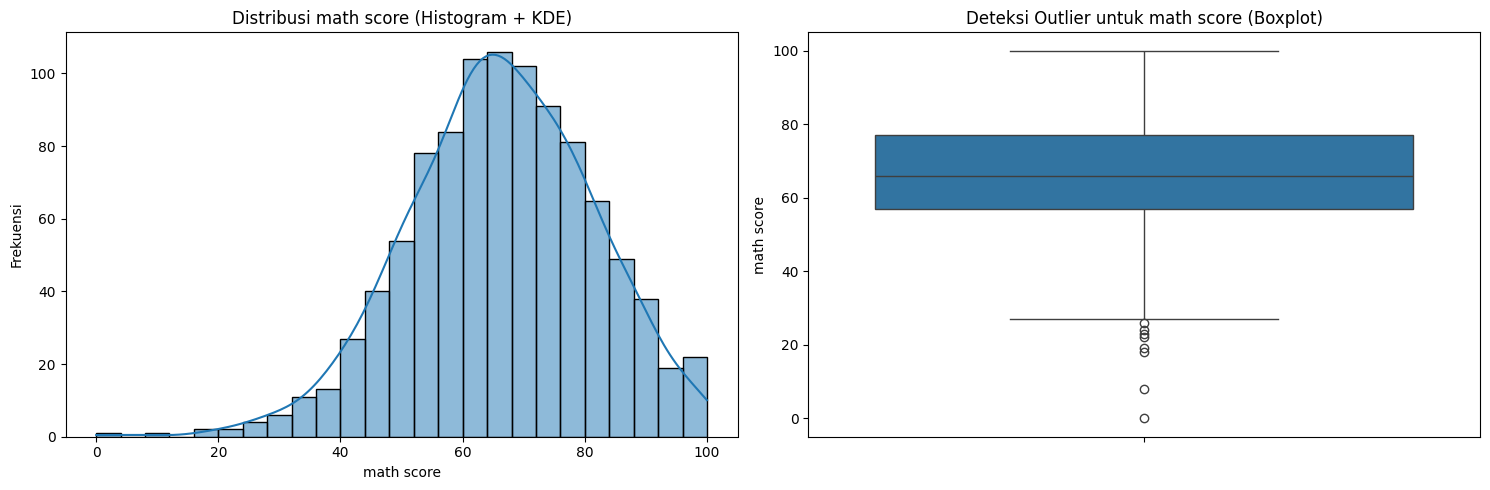

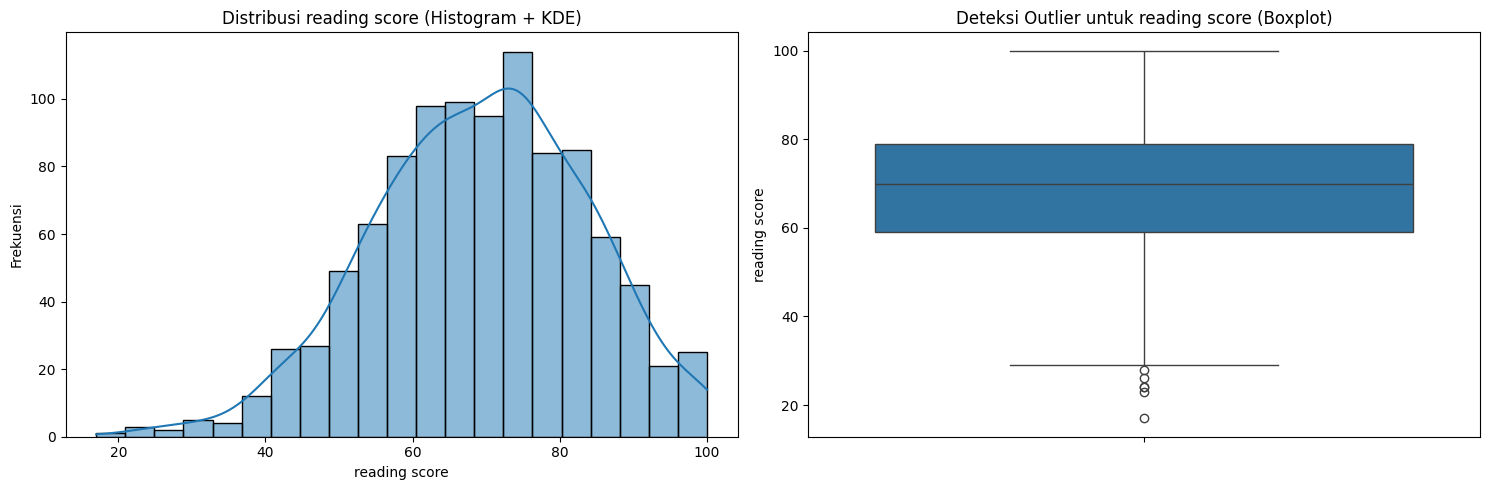

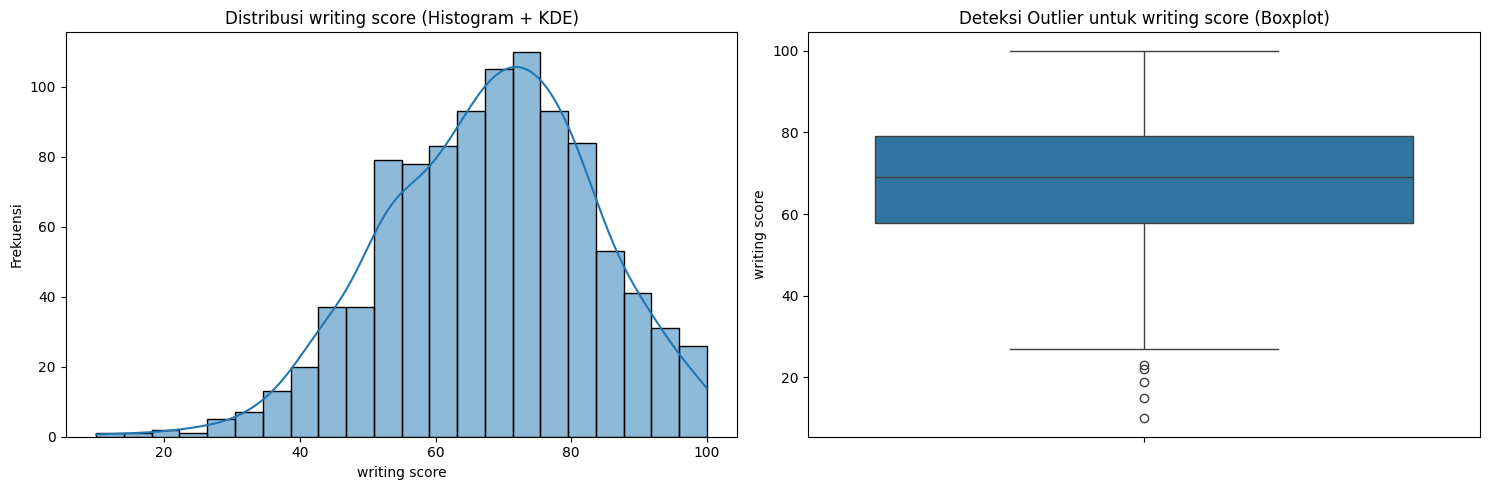


### Analisis Univariat untuk Kolom Kategorikal ###


/tmp/ipykernel_2039/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


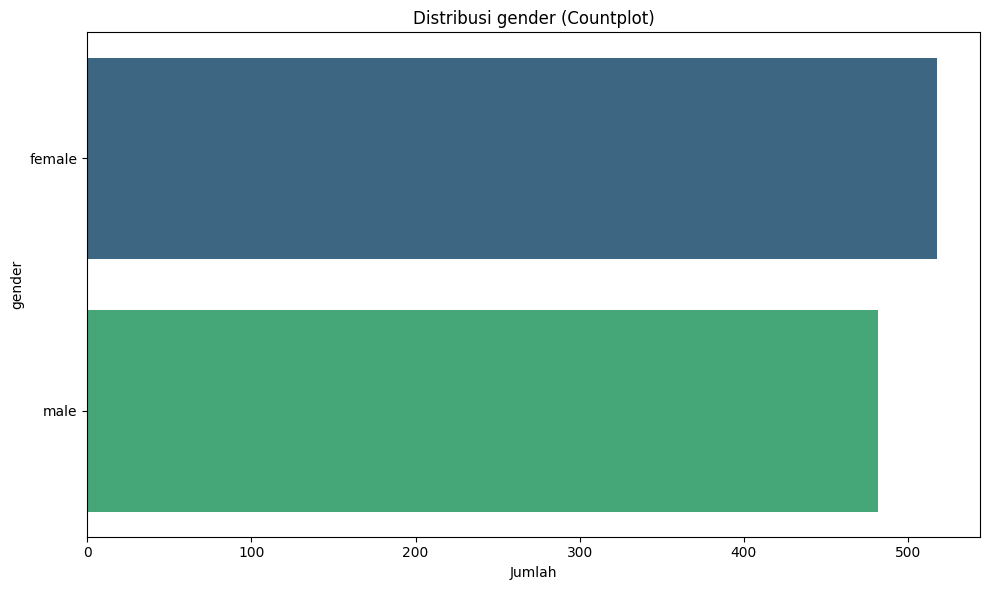

/tmp/ipykernel_2039/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


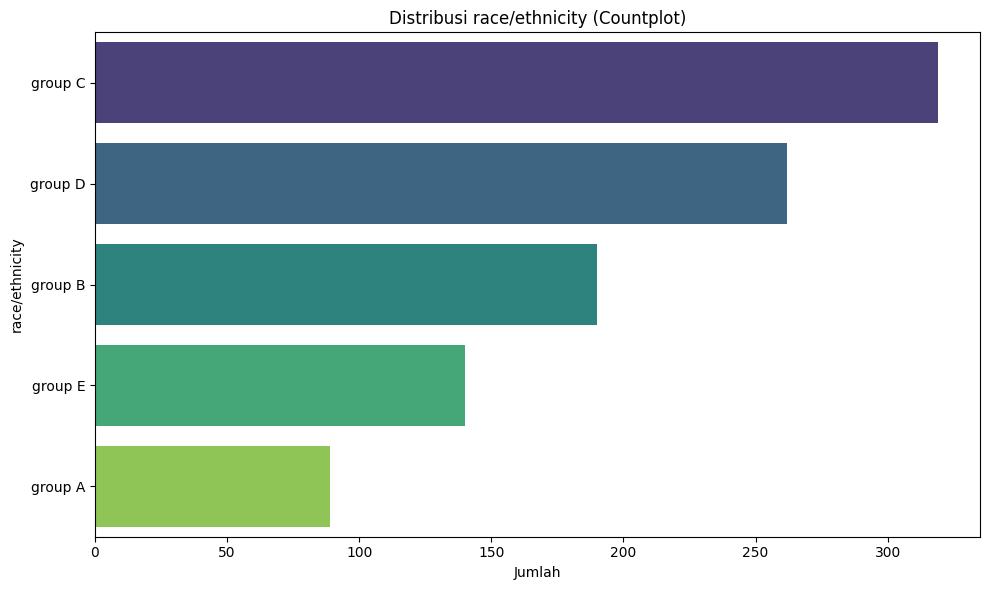

/tmp/ipykernel_2039/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


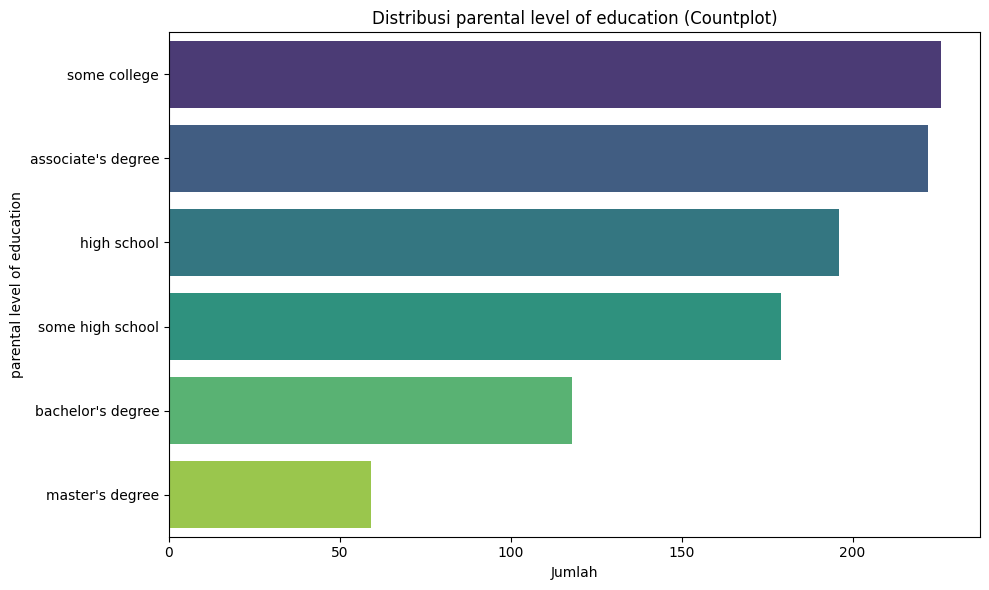

/tmp/ipykernel_2039/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


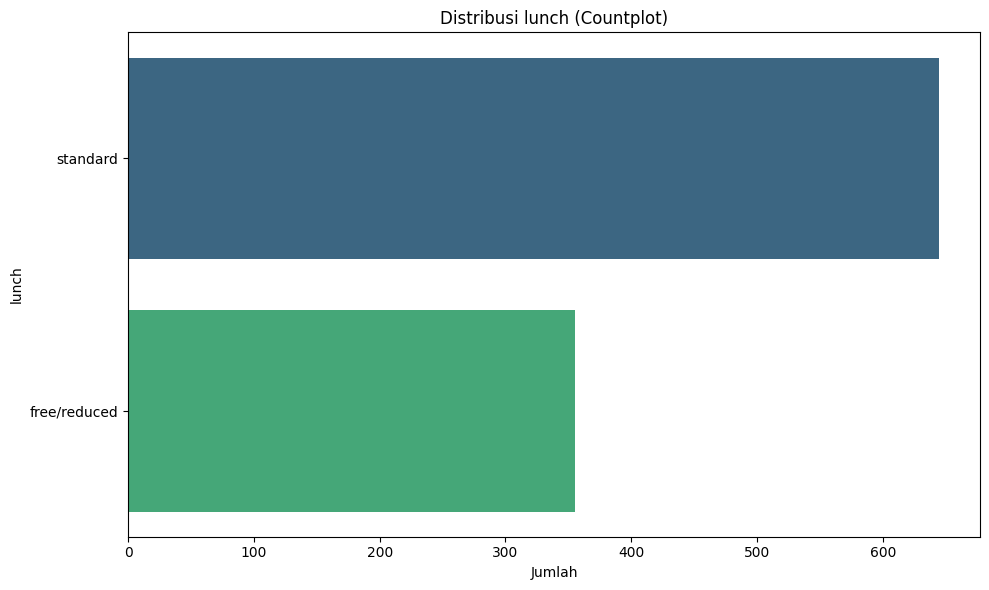

/tmp/ipykernel_2039/2996210070.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')


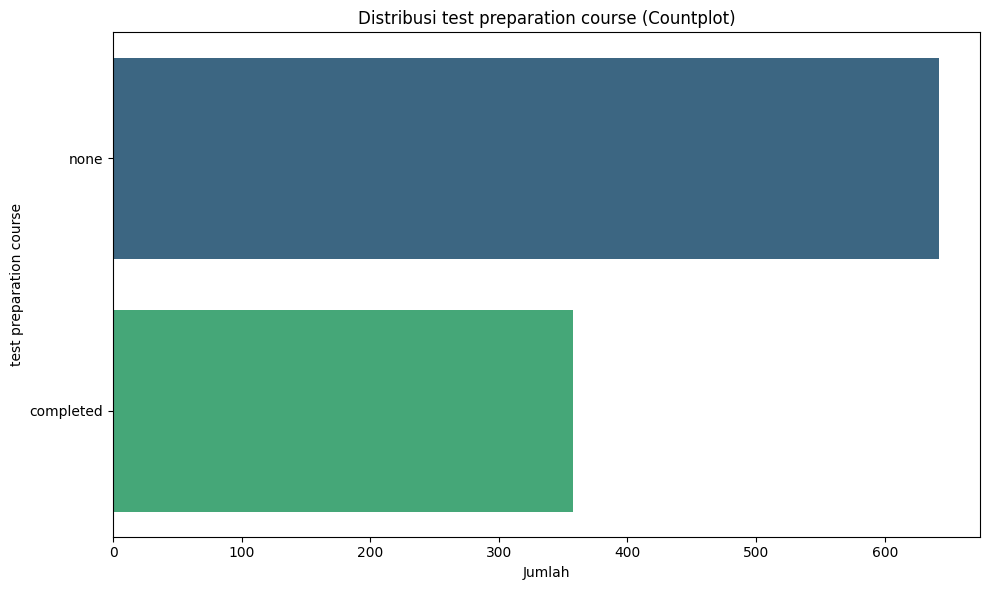

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### Analisis Univariat untuk Kolom Numerik ###")
for kolom in kolom_numerik:
    plt.figure(figsize=(15, 5))

    # Histplot dengan KDE
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, plot pertama
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom} (Histogram + KDE)')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')

    # Boxplot untuk Outliers
    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, plot kedua
    sns.boxplot(y=df[kolom])
    plt.title(f'Deteksi Outlier untuk {kolom} (Boxplot)')
    plt.ylabel(kolom)

    plt.tight_layout()
    plt.show()

print("\n### Analisis Univariat untuk Kolom Kategorikal ###")
for kolom in kolom_kategorikal:
    plt.figure(figsize=(10, 6))
    # Countplot dengan pengurutan berdasarkan frekuensi
    sns.countplot(y=df[kolom], order=df[kolom].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {kolom} (Countplot)')
    plt.xlabel('Jumlah')
    plt.ylabel(kolom)
    plt.tight_layout()
    plt.show()


### Ringkasan Hasil Analisis Univariat

Setelah melakukan analisis univariat pada setiap kolom dalam dataset, berikut adalah interpretasi utama dari plot-plot yang dihasilkan:

**1. Untuk Kolom Numerik (`math score`, `reading score`, `writing score`):**

*   **Distribusi (Histogram dan KDE):**
    *   `math score`, `reading score`, dan `writing score` menunjukkan distribusi yang cenderung normal atau sedikit miring ke kiri (negatively skewed). Ini berarti sebagian besar siswa mendapatkan skor di atas rata-rata.
    *   Namun, ada juga konsentrasi skor yang lebih rendah, terutama di sekitar angka 0-20 untuk semua mata pelajaran, menunjukkan adanya siswa dengan kinerja yang sangat rendah.
    *   Kurva KDE mengkonfirmasi pola ini, dengan puncak di sekitar nilai 60-70 dan penurunan bertahap di kedua sisi.

*   **Deteksi Outlier (Boxplot):**
    *   **`math score`:** Terdapat banyak *outlier* di sisi bawah (nilai rendah), menunjukkan beberapa siswa mendapatkan skor yang jauh di bawah sebagian besar populasi. Nilai terendah mencapai 0.
    *   **`reading score` dan `writing score`:** Juga terlihat *outlier* di sisi bawah, meskipun tidak sebanyak *math score*. Nilai terendah untuk membaca dan menulis juga sangat rendah.
    *   Keberadaan *outlier* di nilai rendah menunjukkan bahwa ada sekelompok siswa yang mungkin menghadapi kesulitan signifikan dalam ujian ini.

**2. Untuk Kolom Kategorikal (`gender`, `race/ethnicity`, `parental level of education`, `lunch`, `test preparation course`):**

*   **`gender`:** Distribusi gender menunjukkan bahwa jumlah siswa perempuan sedikit lebih banyak (sekitar 52%) daripada siswa laki-laki (sekitar 48%).

*   **`race/ethnicity`:** Dataset ini terdiri dari lima kelompok ras/etnis (Group A, B, C, D, E). Group C adalah kelompok terbesar, diikuti oleh Group D, sementara Group A adalah yang terkecil.

*   **`parental level of education`:** Tingkat pendidikan orang tua sangat bervariasi. Kategori 'some college', 'associate's degree', dan 'high school' adalah yang paling sering muncul, menunjukkan spektrum pendidikan orang tua yang luas. Kategori 'master's degree' dan 'bachelor's degree' lebih sedikit.

*   **`lunch`:** Mayoritas siswa (sekitar 64%) mendapatkan makan siang 'standard', sedangkan sisanya mendapatkan 'free/reduced'. Perbedaan ini mungkin memiliki implikasi terhadap kinerja siswa.

*   **`test preparation course`:** Sebagian besar siswa (sekitar 64%) tidak menyelesaikan kursus persiapan ujian ('none'), sementara sekitar 36% menyelesaikannya ('completed'). Ini bisa menjadi faktor penting untuk dianalisis kaitannya dengan nilai ujian.

Analisis univariat ini telah memberikan gambaran mendalam tentang karakteristik setiap variabel secara individual, menyoroti pola distribusi, potensi anomali (terutama pada skor numerik), dan komposisi kategori. Informasi ini merupakan dasar yang kuat untuk melanjutkan ke analisis bivariat dan multivariat guna menemukan hubungan antar variabel.

## **Analisis Bivariat & Multivariat (Bivariate & Multivariate Analysis)**

### 1. Heatmap Korelasi Antar Kolom Numerik ###


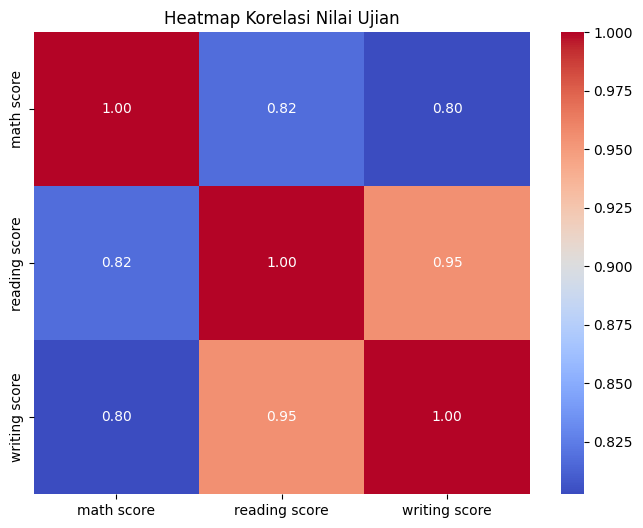


### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue) ###


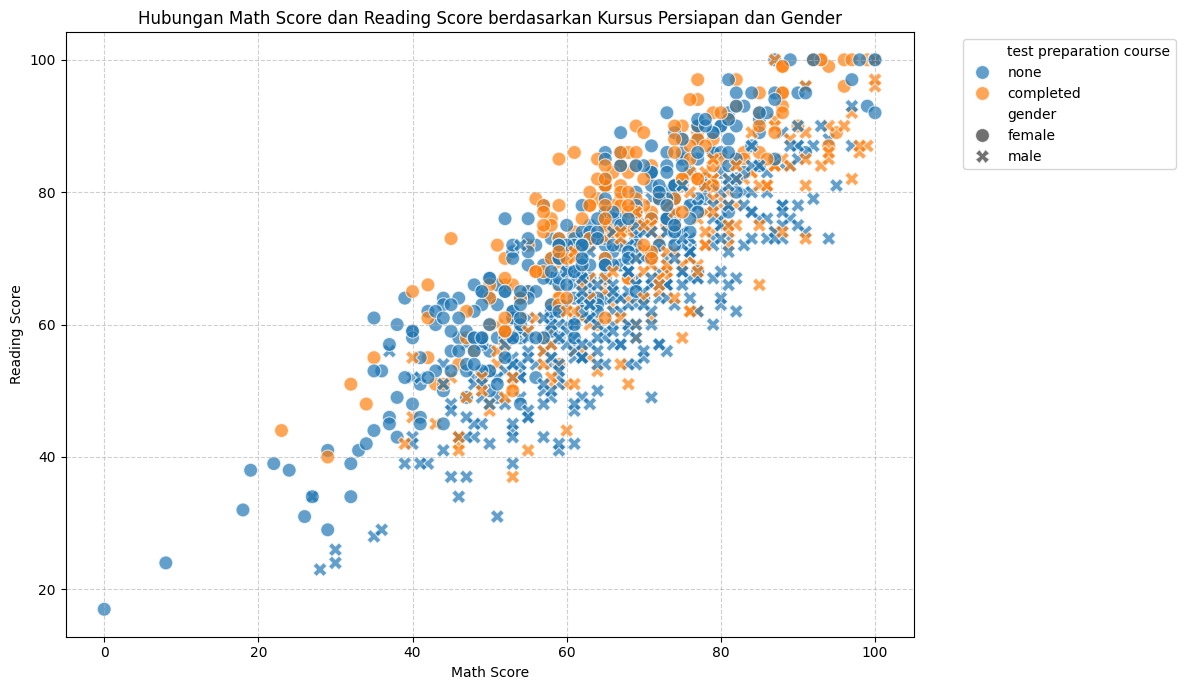

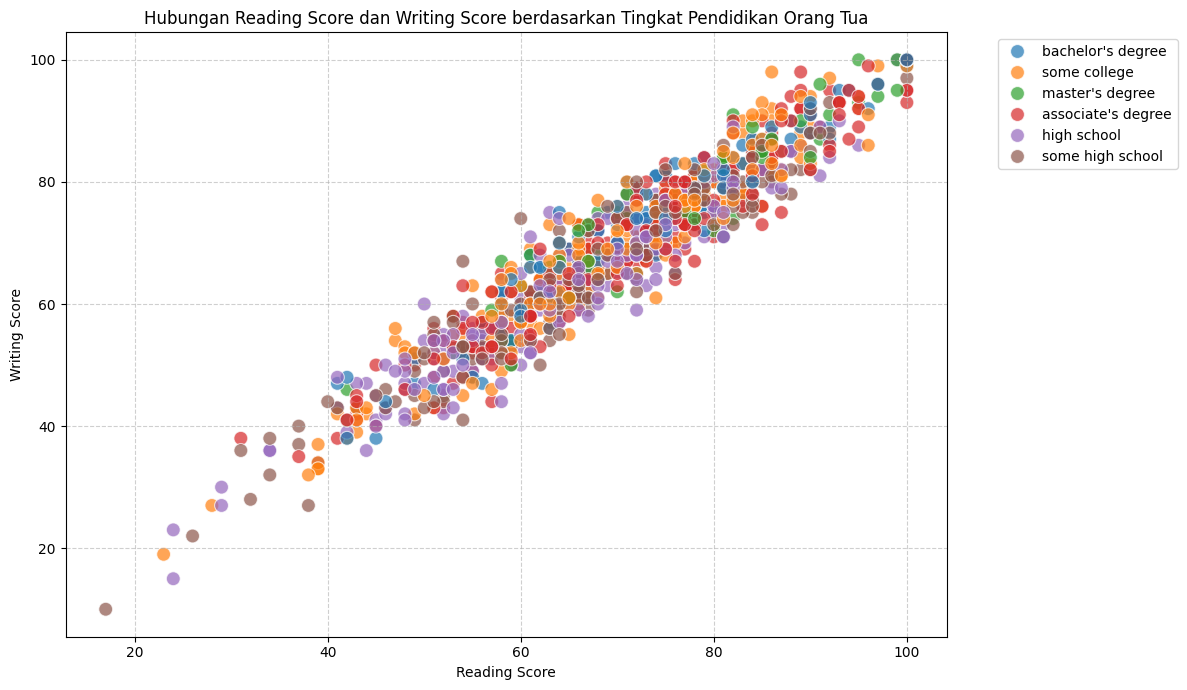


### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###


/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


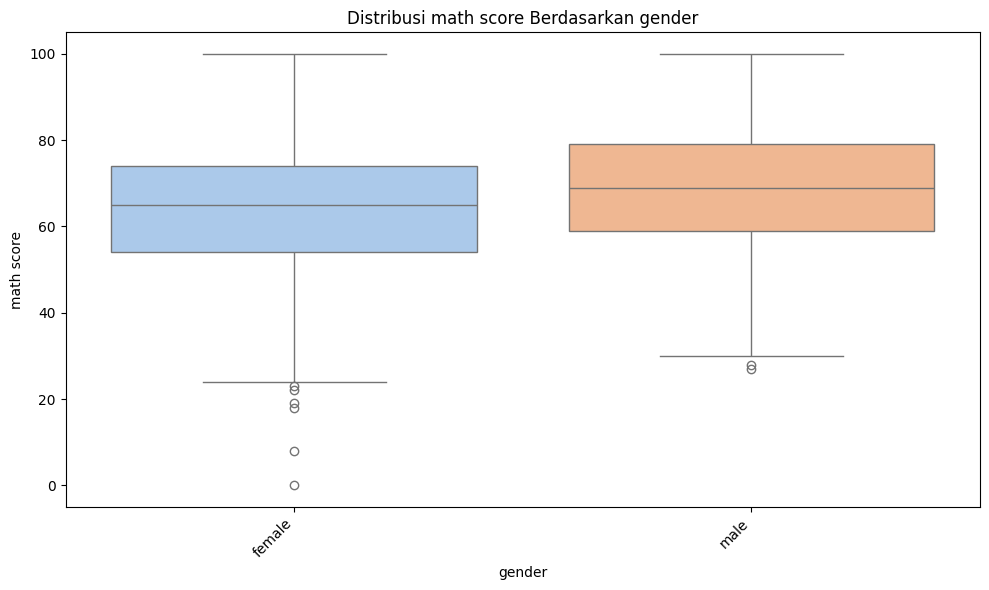

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


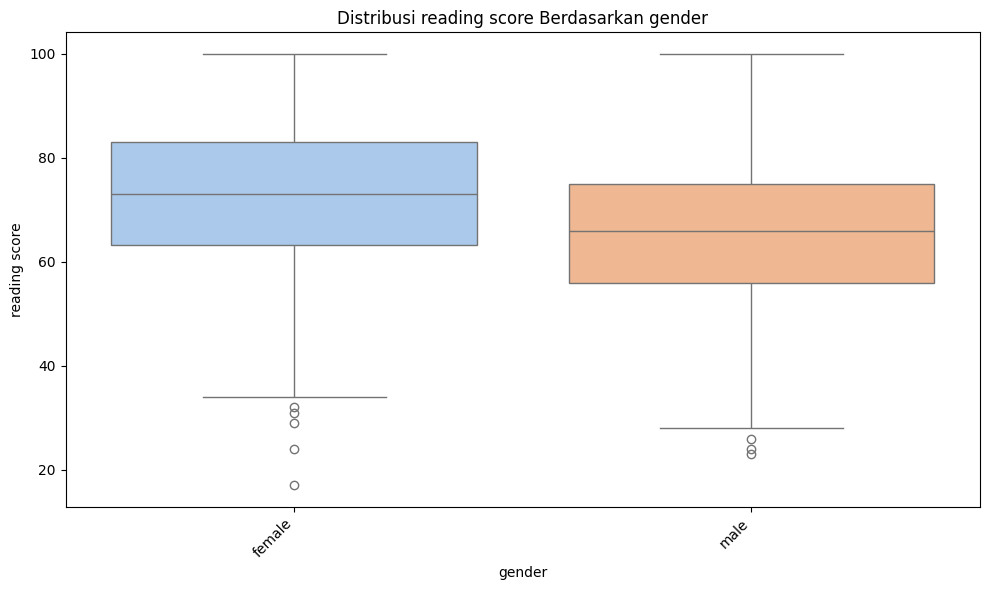

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


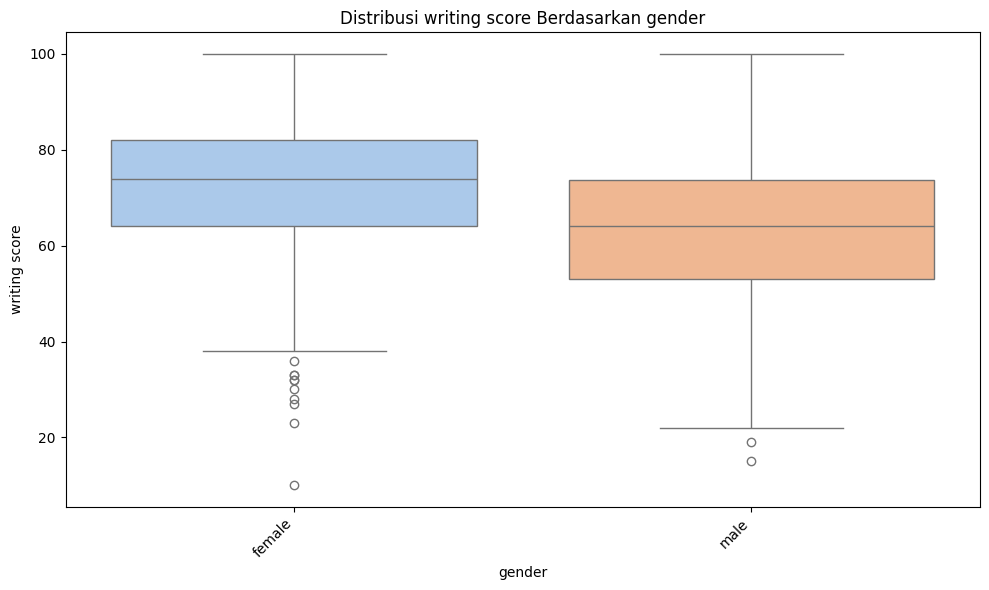

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


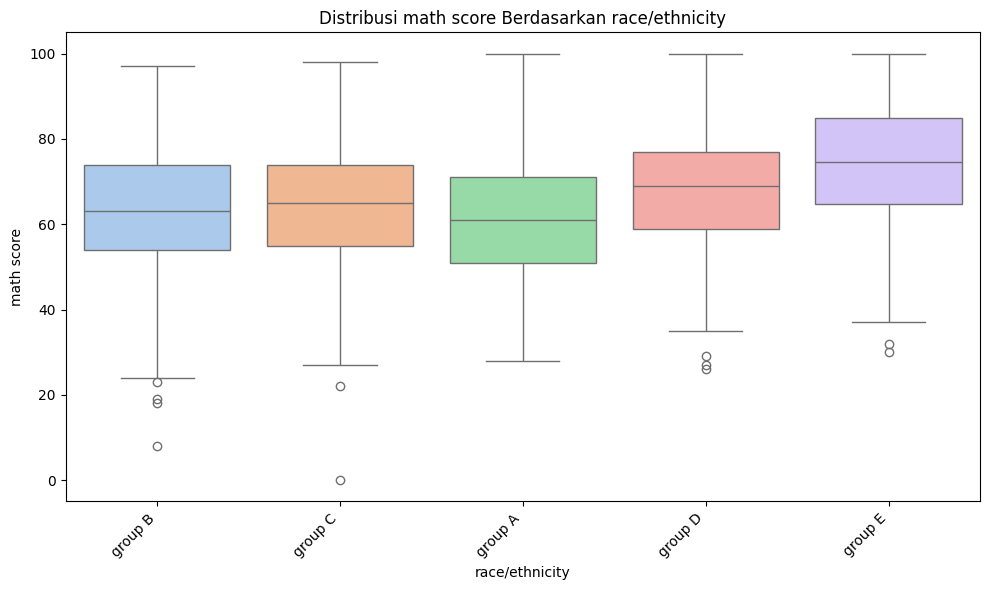

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


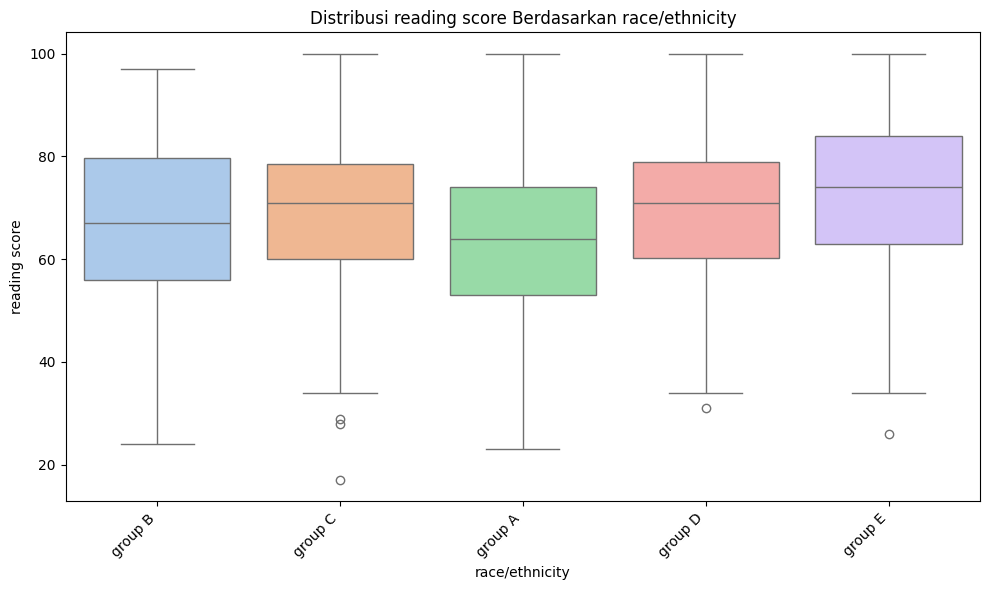

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


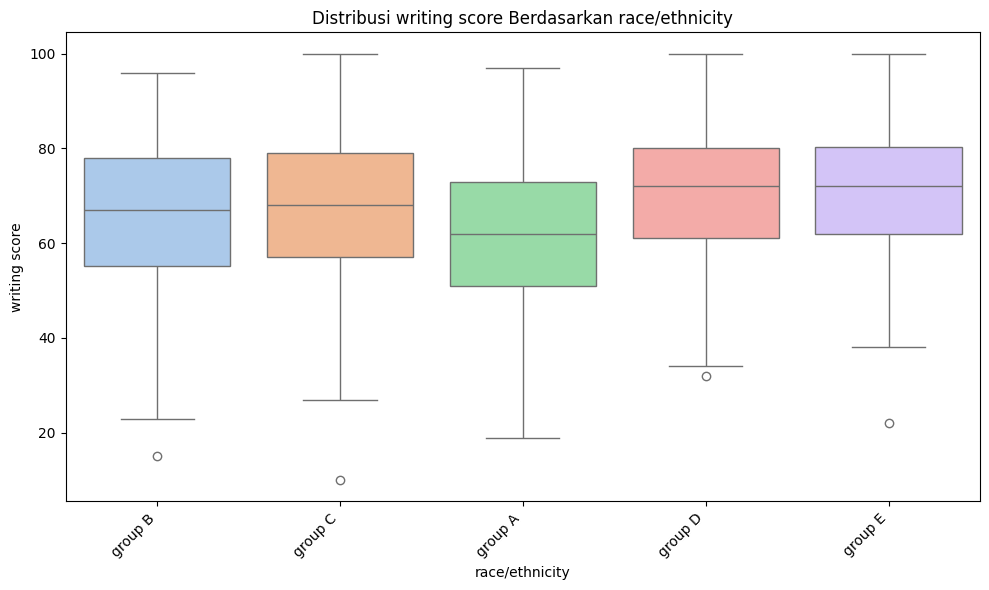

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


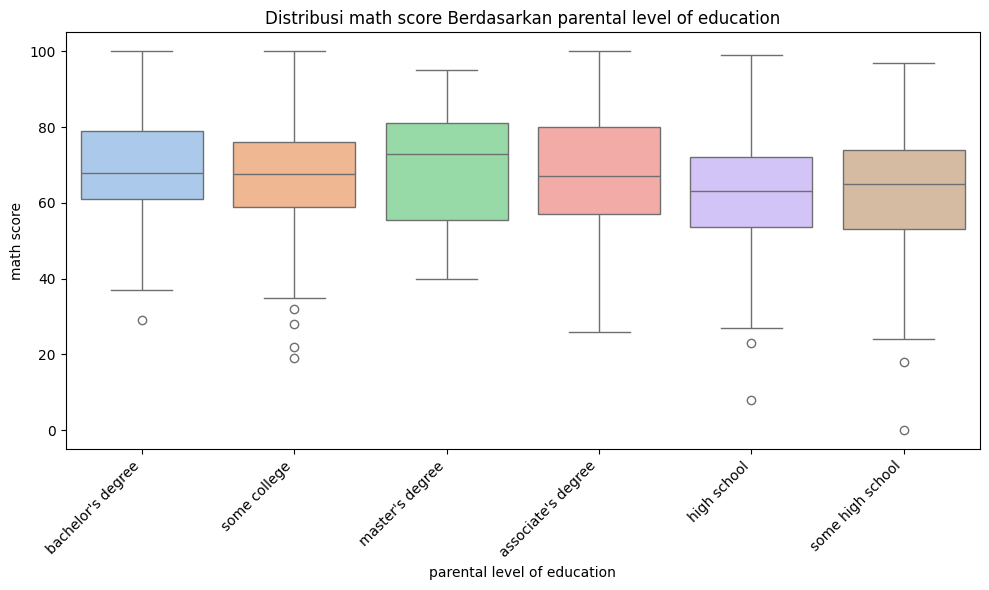

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


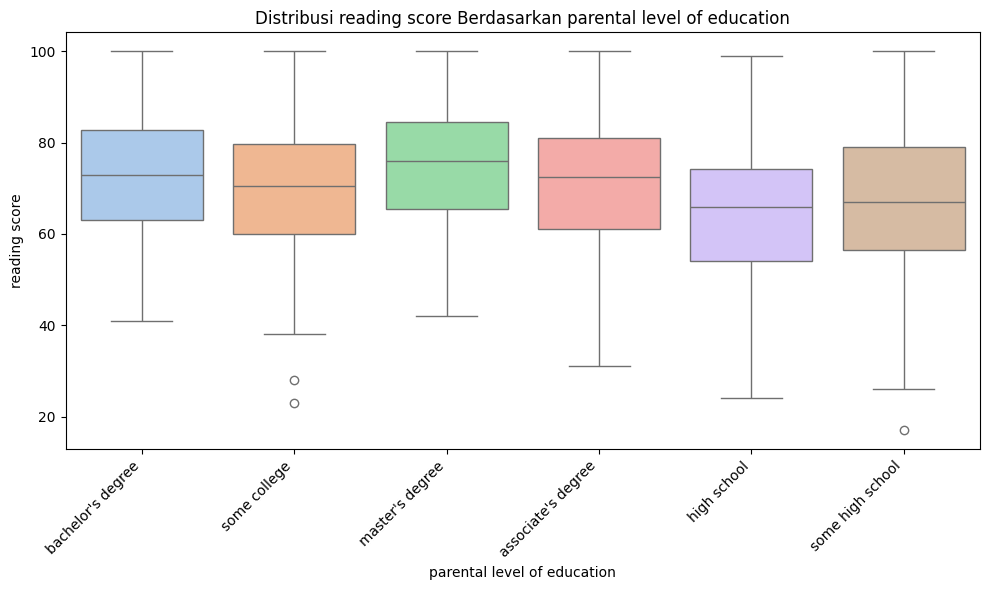

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


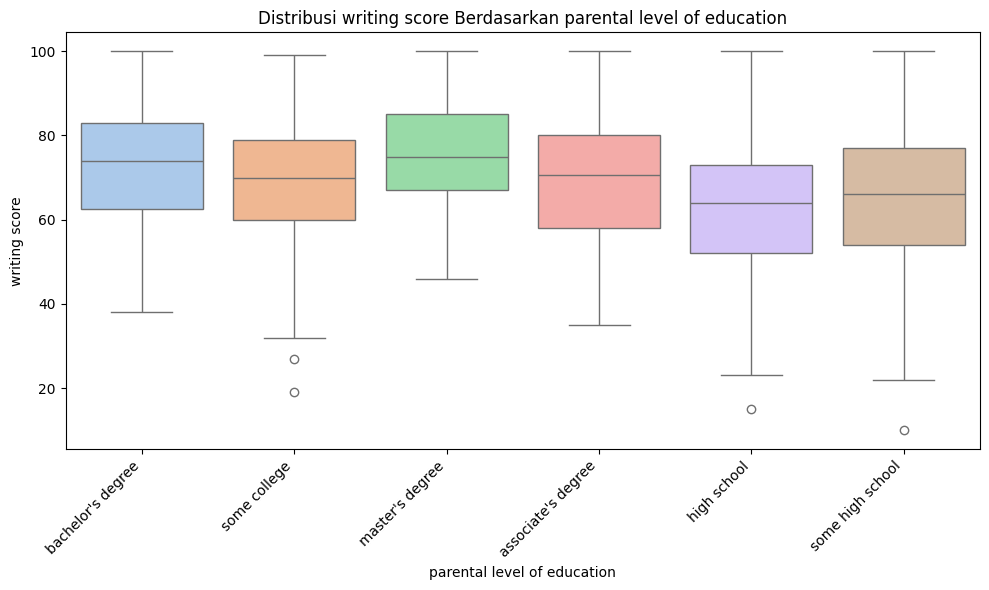

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


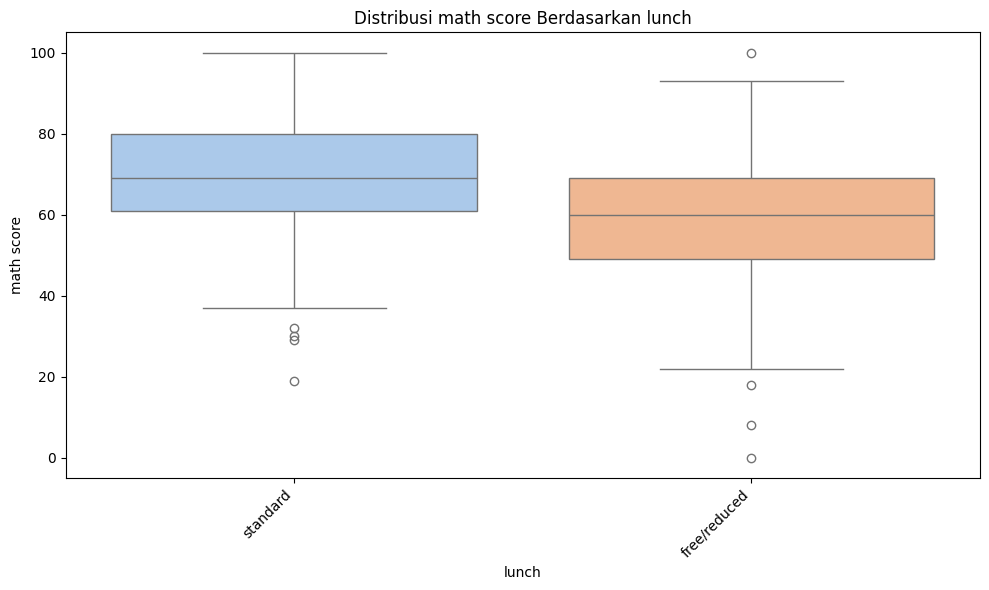

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


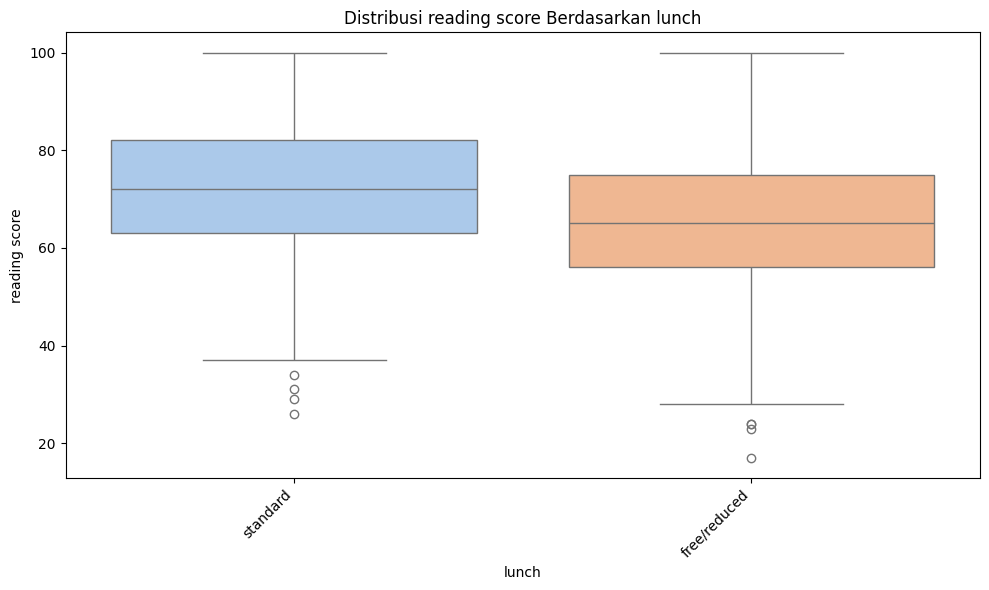

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


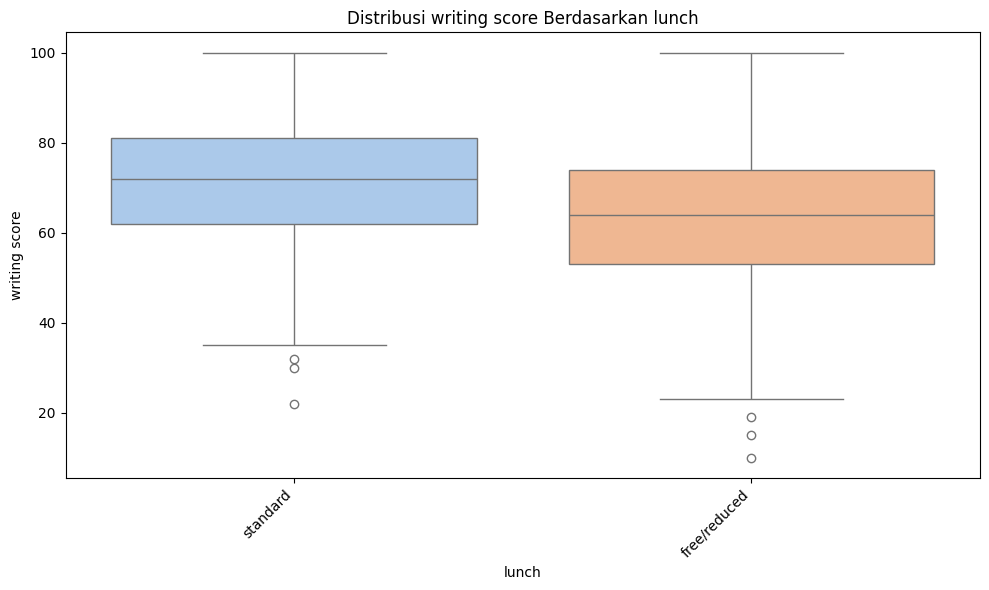

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


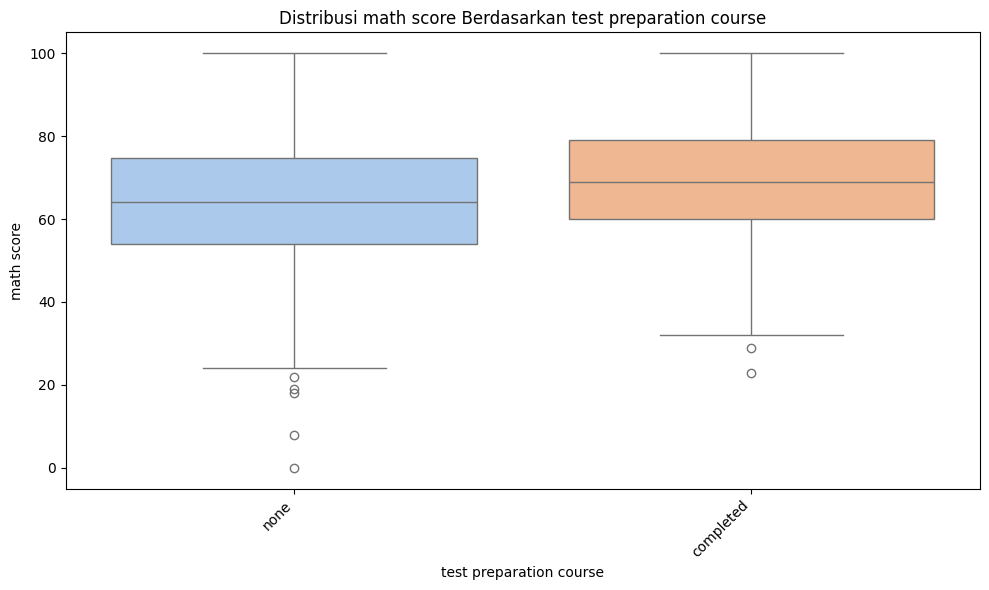

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


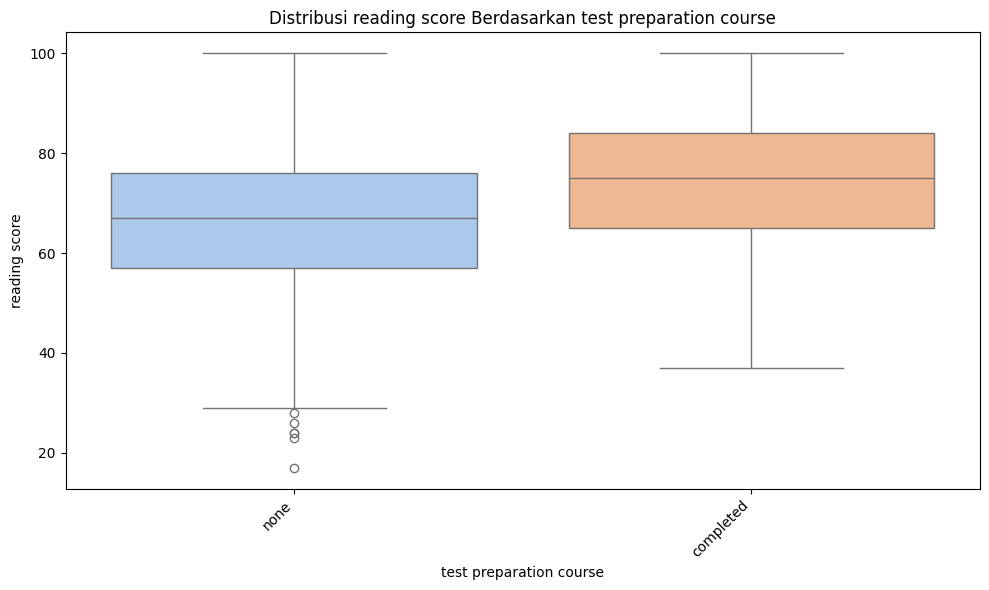

/tmp/ipykernel_2039/3683220891.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')


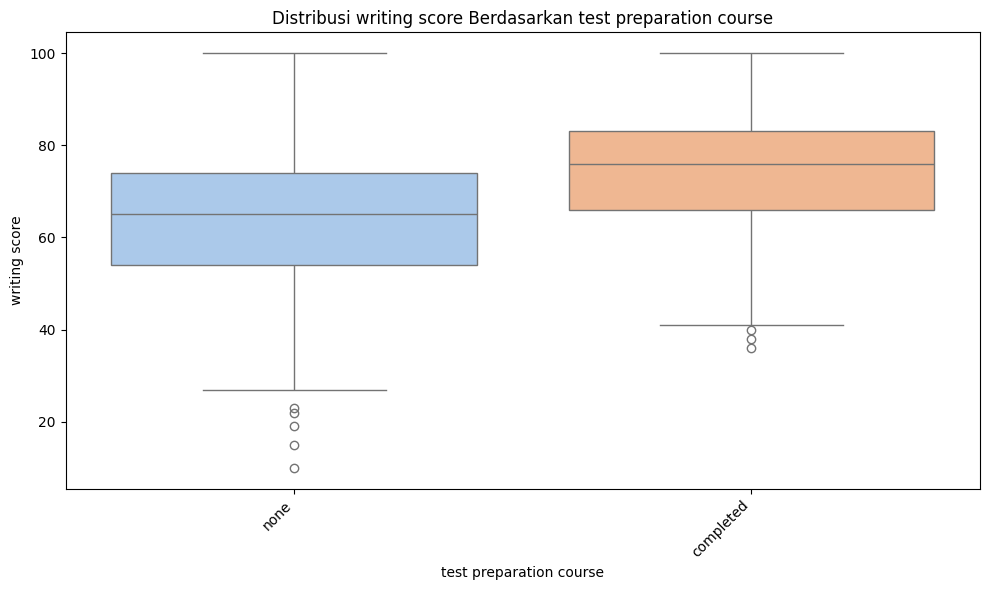

In [ ]:
# Memisahkan kolom numerik dan kategorikal
kolom_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
kolom_kategorikal = df.select_dtypes(include=['object']).columns.tolist()

print("### 1. Heatmap Korelasi Antar Kolom Numerik ###")
plt.figure(figsize=(8, 6))
correlation_matrix = df[kolom_numerik].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Nilai Ujian')
plt.show()

print("\n### 2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue) ###")
# Contoh: Math Score vs Reading Score, diwarnai berdasarkan 'test preparation course'
# dan dibedakan style berdasarkan 'gender'
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='math score', y='reading score', hue='test preparation course', style='gender', s=100, alpha=0.7)
plt.title('Hubungan Math Score dan Reading Score berdasarkan Kursus Persiapan dan Gender')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Contoh lain: Reading Score vs Writing Score, diwarnai berdasarkan 'parental level of education'
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='reading score', y='writing score', hue='parental level of education', s=100, alpha=0.7)
plt.title('Hubungan Reading Score dan Writing Score berdasarkan Tingkat Pendidikan Orang Tua')
plt.xlabel('Reading Score')
plt.ylabel('Writing Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n### 3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori ###")
# Untuk setiap kolom kategorikal, bandingkan dengan setiap kolom numerik
for kat_kolom in kolom_kategorikal:
    for num_kolom in kolom_numerik:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=kat_kolom, y=num_kolom, palette='pastel')
        plt.title(f'Distribusi {num_kolom} Berdasarkan {kat_kolom}')
        plt.xlabel(kat_kolom)
        plt.ylabel(num_kolom)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


### Ringkasan Hasil Analisis Bivariat & Multivariat

Setelah melakukan analisis bivariat dan multivariat pada dataset, berikut adalah interpretasi utama dari plot-plot yang dihasilkan:

**1. Heatmap Korelasi Antar Kolom Numerik (Nilai Ujian):**

*   `Heatmap` menunjukkan korelasi positif yang sangat kuat antara semua kolom nilai ujian (`math score`, `reading score`, dan `writing score`).
*   Korelasi antara `reading score` dan `writing score` sangat tinggi (0.95), menunjukkan bahwa siswa yang pandai membaca cenderung juga pandai menulis, dan sebaliknya. Ini sangat masuk akal karena kedua keterampilan seringkali saling berhubungan.
*   Korelasi antara `math score` dengan `reading score` (0.81) dan `writing score` (0.80) juga kuat, meskipun sedikit lebih rendah dari korelasi antara membaca dan menulis. Ini menunjukkan bahwa siswa yang berprestasi di satu bidang (misalnya, matematika) cenderung juga berprestasi di bidang lain, mengindikasikan adanya kemampuan akademik umum.

**2. Scatter Plot Antar Kolom Numerik dengan Variabel Kategorikal (Hue):**

*   **`math score` vs `reading score` berdasarkan `test preparation course` dan `gender`:**
    *   Terlihat pola linier positif yang jelas: semakin tinggi nilai matematika, semakin tinggi pula nilai membaca. Ini mengkonfirmasi korelasi kuat yang terlihat pada *heatmap*.
    *   Siswa yang menyelesaikan kursus persiapan ujian (`completed`) cenderung memiliki skor yang lebih tinggi di kedua mata pelajaran dibandingkan dengan yang tidak (`none`). Titik-titik biru (completed) cenderung berada di area kanan atas grafik.
    *   Secara umum, siswi (`female`) cenderung memiliki skor membaca dan menulis yang lebih tinggi dibandingkan siswa laki-laki (`male`), terutama di rentang skor menengah ke atas, sementara siswa laki-laki mungkin memiliki sedikit keunggulan di matematika pada beberapa rentang skor, namun perbedaan ini tidak selalu konsisten di seluruh spektrum.
*   **`reading score` vs `writing score` berdasarkan `parental level of education`:**
    *   Korelasi positif yang sangat kuat antara nilai membaca dan menulis kembali terlihat jelas.
    *   Meskipun tidak ada pemisahan yang sangat tajam, ada indikasi bahwa siswa dengan orang tua yang memiliki tingkat pendidikan lebih tinggi (`master's degree`, `bachelor's degree`) cenderung memiliki skor yang sedikit lebih tinggi di kedua bidang ini, meskipun siswa dari semua latar belakang pendidikan orang tua dapat mencapai skor tinggi.

**3. Boxplot Perbandingan Kolom Numerik Berdasarkan Kategori:**

*   **Gender vs. Nilai:**
    *   `Female` cenderung memiliki median dan distribusi skor `reading` dan `writing` yang lebih tinggi dibandingkan `male`.
    *   `Male` cenderung memiliki median dan distribusi skor `math` yang sedikit lebih tinggi daripada `female`.
*   **Race/Ethnicity vs. Nilai:** Ada perbedaan median skor antar kelompok ras/etnis. Misalnya, Group E seringkali menunjukkan median skor tertinggi di semua mata pelajaran, sementara Group A cenderung memiliki median terendah. Ini menunjukkan disparitas kinerja berdasarkan kelompok etnis.
*   **Parental Level of Education vs. Nilai:** Secara umum, semakin tinggi tingkat pendidikan orang tua, semakin tinggi pula median skor siswa. Siswa dengan orang tua yang memiliki 'master's degree' atau 'bachelor's degree' cenderung memiliki skor lebih tinggi dibandingkan mereka yang orang tuanya hanya memiliki 'high school' atau 'some high school'.
*   **Lunch vs. Nilai:** Siswa yang menerima makan siang 'standard' memiliki median skor yang secara signifikan lebih tinggi di semua mata pelajaran dibandingkan siswa yang menerima makan siang 'free/reduced'. Ini menunjukkan hubungan antara status sosial ekonomi dan kinerja akademik.
*   **Test Preparation Course vs. Nilai:** Siswa yang 'completed' (menyelesaikan) kursus persiapan ujian memiliki median skor yang jauh lebih tinggi di semua mata pelajaran dibandingkan dengan siswa yang 'none' (tidak mengambil kursus). Ini adalah indikator kuat bahwa kursus persiapan ujian memiliki dampak positif pada kinerja siswa.

Secara keseluruhan, analisis bivariat dan multivariat ini menyoroti hubungan penting antara variabel demografi/sosial dan kinerja akademik siswa. Variabel seperti kursus persiapan ujian, tingkat pendidikan orang tua, dan jenis makan siang menunjukkan dampak yang cukup jelas terhadap nilai ujian.

## **Catatan Kesimpulan dan Langkah Selanjutnya (Insights & Next Steps)**

### Ringkasan Temuan Utama dari Eksplorasi Data (EDA)

Berdasarkan analisis yang telah dilakukan pada dataset "Students Performance in Exams", beberapa temuan kunci dapat disimpulkan:

1.  **Kualitas Data Sangat Baik:** Dataset ini bersih, tanpa adanya *missing values* atau duplikasi baris, sehingga siap untuk analisis lebih lanjut tanpa perlu penanganan data kotor yang ekstensif.

2.  **Korelasi Kuat Antar Nilai Ujian:** Terdapat korelasi positif yang sangat kuat antara semua mata pelajaran (matematika, membaca, menulis). Terutama, `reading score` dan `writing score` memiliki korelasi yang hampir sempurna, menunjukkan bahwa kemampuan membaca sangat terkait erat dengan kemampuan menulis. Hal ini mengindikasikan adanya kemampuan akademik umum yang mempengaruhi kinerja siswa di berbagai mata pelajaran.

3.  **Dampak Positif Kursus Persiapan Ujian:** Siswa yang menyelesaikan kursus persiapan ujian (`test preparation course: completed`) secara konsisten menunjukkan kinerja yang jauh lebih baik di semua mata pelajaran dibandingkan dengan siswa yang tidak mengambil kursus. Ini adalah faktor prediktif yang sangat kuat untuk keberhasilan akademik.

4.  **Pengaruh Tingkat Pendidikan Orang Tua:** Ada kecenderungan positif antara tingkat pendidikan orang tua dan skor ujian siswa. Umumnya, siswa dengan orang tua yang memiliki tingkat pendidikan lebih tinggi (misalnya, `master's degree`, `bachelor's degree`) cenderung memiliki skor rata-rata yang lebih tinggi.

5.  **Perbedaan Kinerja Berdasarkan Gender:** Siswa perempuan cenderung berkinerja lebih baik dalam mata pelajaran membaca dan menulis, sementara siswa laki-laki memiliki sedikit keunggulan dalam matematika, meskipun perbedaan ini tidak selalu signifikan di semua rentang skor.

6.  **Disparitas Berdasarkan Kelompok Ras/Etnis:** Terdapat perbedaan yang terlihat dalam kinerja rata-rata antar kelompok ras/etnis. Beberapa kelompok (misalnya, Group E) menunjukkan skor rata-rata yang lebih tinggi secara konsisten dibandingkan kelompok lain (misalnya, Group A).

7.  **Hubungan Status Sosial Ekonomi dengan Kinerja:** Siswa yang mendapatkan makan siang 'standard' (yang dapat diinterpretasikan sebagai indikator status sosial ekonomi yang lebih baik) menunjukkan skor yang secara signifikan lebih tinggi di semua mata pelajaran dibandingkan dengan siswa yang mendapatkan makan siang 'free/reduced'. Ini menyoroti potensi dampak faktor sosial ekonomi terhadap prestasi akademik.

8.  **Keberadaan Outlier di Nilai Rendah:** Terutama di `math score`, ditemukan banyak *outlier* di sisi bawah (nilai 0), menunjukkan bahwa ada sejumlah siswa yang berkinerja sangat buruk. Ini mungkin memerlukan investigasi lebih lanjut untuk memahami akar penyebabnya.

### Langkah Selanjutnya:

*   **Pemodelan Prediktif:** Temuan ini dapat digunakan untuk membangun model prediktif untuk memprediksi `math score`, `reading score`, atau `writing score` berdasarkan variabel-variabel demografi dan status kursus persiapan.
*   **Analisis Kausal:** Studi lebih lanjut dapat dilakukan untuk mencoba mengidentifikasi hubungan kausal (misalnya, apakah kursus persiapan ujian *menyebabkan* peningkatan nilai, atau apakah siswa yang sudah baik yang cenderung mengambil kursus).
*   **Intervensi:** Berdasarkan faktor-faktor yang teridentifikasi, intervensi dapat dirancang untuk mendukung siswa yang berisiko rendah kinerja, seperti menyediakan program dukungan untuk persiapan ujian atau dukungan lainnya.